# Should we discount tomorrow?
### From a fresh-food manager's question to a specific daily recommendation

**MAIB7002 · Group Q · Lisa's pipeline extension**  
Aashish Omprakash Pareek · Yuanyuan Yin · Lingyu Chen

At the end of a trading day, a fresh-food category manager has to set tomorrow's discount before knowing
how much will sell. Keeping the price high may leave stock unsold. Cutting it too far may give away value
on sales that would have happened anyway. The useful answer is a decision for **one product, in one store,
on one day**: keep the price, offer a particular discount, or check the situation before deciding.

Our project builds a small decision-support prototype around that question. First we learn to predict
next-day sales from public retail records. Then we compare a menu of possible discounts and explain
which recommendation, if any, passes our checks.

**The journey:** the business problem → suitable data → five stores worth studying → a simple forecast to beat
→ the teammate's evidence → Lisa's extension → the gap between predicting and deciding → a real recommendation.

No machine-learning background is needed for the main story. The technical appendix explains the algorithms,
shows a live model calculation and contains the complete experiment table. Code is available at each step;
in the HTML report it can be expanded when needed.

## 1. Why this decision is worth solving

Fresh food has a limited selling window. A manager who discounts too late risks unsold goods; a manager
who discounts too early may earn less per sale without enough extra volume to compensate. Across many
store-product combinations, it is difficult to judge these trade-offs consistently from recent sales alone.
A useful assistant should make the comparison explicit, show the evidence behind it and recognize when
it lacks enough information to advise.

The original project idea concerned evening bakery markdowns. The available public data led us to a
more specific, feasible scope: **tomorrow's daily discount for a Dingdong store-product**. There is one
recorded discount rate per day, so this study does not optimize a sequence of half-hourly markdowns.

We separate the business ambition from what this dataset lets us measure:

| What the manager ultimately cares about | What this project can check |
|---|---|
| Sell perishable goods without unnecessary discounting | Whether predicted next-day sales improve on a simple recent-sales average |
| Choose whether to discount and by how much | Whether a suggested rate has historical support and passes explicit sales/value checks |
| Increase revenue and reduce waste | These are motivations; the dataset does not let us verify those outcomes for a new policy |

This gives us two connected tasks. **Forecasting** produces a sales estimate that we can compare with a
recorded outcome. **Decision support** uses several forecasts to compare hypothetical discounts. An
accurate forecast is necessary evidence for this approach, but does not by itself validate the decision.

## 2. Why use these data?

We use [Dingdong's FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K),
a public dataset licensed CC BY 4.0. It contains actual retail records rather than demand generated by
our own simulator. It is a useful fit because the same products are observed over time at different
stores, alongside daily discounts, sales, calendar information and stockout signals.

One row describes **one store, one product and one date**. A store-product *series* is that pair's history
across dates. The same product in two stores forms two separate series: its sales history must not be
mixed across locations.

| Available evidence | How it helps the decision | What it does not establish |
|---|---|---|
| Daily sales and discounts | Learn how recorded sales vary with recent history and price conditions | What would have sold at every alternative price |
| Previous-day stockout hours | Flag that observed sales may be constrained by availability | Stock quantity, batch age or tomorrow's freshness |
| Calendar and activity information | Describe the context known at the decision time | Tomorrow's realized sales or realized stockouts |
| Store and product identifiers | Distinguish recurring trading contexts | Store names, customer profiles or product shelf life |

The sales field is **normalized observed sales**. A value such as 1.2 is not 1.2 items, kilograms or dollars.
If stock is unavailable, recorded sales can also understate customers' demand. These facts shape both
our prediction target and the language we use for the final recommendation.

The full source covers 50,000 store-product series in 898 stores across 18 cities. Its original training
file spans 90 days, followed by a seven-day evaluation file. The download script obtains a fixed version
from Hugging Face, verifies it, and stores it locally. The delivered notebook includes small derived
artifacts so the story and live example can also run offline.

That still leaves an important design choice: which part of this large dataset can support a manageable,
meaningful first pricing study?

## 3. How 50,000 histories became five stores

A product that is always full price tells us little about different discounts. A product that is always
on promotion offers little comparison with ordinary trading. We therefore keep store-product histories
with both kinds of days and repeated changes between them.

We follow the teammate's original selection exactly:

| Selection rule | Reason for using it |
|---|---|
| Discounted on 15%–85% of training days | Retain both discounted and non-discounted observations |
| At least six switches between those states | Avoid relying on just one long promotion period |
| Zero sales on fewer than 20% of days | Avoid histories dominated by zero recorded activity |

For this selection step, a day is classified as discounted only when the price rate is **below 0.95**:
more than 5% off. A day at exactly 0.95 is on the other side of this particular threshold. A change from
0.90 to 0.80 does not count as a state switch because both are already discounted.

After filtering the histories, we count how many eligible products each store has and choose the **five
stores with the most eligible series**. We did not first choose a city or select stores because their
models scored well. All five selected stores happen to be in city 0. We then keep only their eligible
products, rather than every product sold in those stores.

In [1]:
from pathlib import Path
import sys, json, hashlib, subprocess
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    raise RuntimeError("Open this notebook from the repository root")
sys.path.insert(0, str(ROOT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from finalproject_pricingml import config as C, v2
OUT = ROOT / "results" / "v2"
pd.set_option("display.precision", 5)
%matplotlib inline

# The default reads verified results; the live example later refits two models.
# Set True only to repeat the full 66-fit experiment after downloading the raw files.
RERUN_FULL_EXPERIMENT = False
if RERUN_FULL_EXPERIMENT:
    v2.run(OUT)
    subprocess.run([sys.executable, str(ROOT / "scripts" / "build_story_evidence.py")], check=True)
verification = v2.verify_saved(OUT)
feat = pd.read_parquet(OUT / "features.parquet")
plan = json.loads((OUT / "experiment_plan.json").read_text())
selection = json.loads((OUT / "selection.json").read_text())
comparison = pd.read_csv(OUT / "comparison.csv")
metrics = comparison.set_index("model")
winner = selection["selected_model"]
test_predictions = pd.read_csv(OUT / "test_predictions.csv", parse_dates=["dt"])
evidence = json.loads((OUT / "story_evidence.json").read_text())
for key, filename in [("features","features.parquet"), ("discount_response","discount_response.csv"),
                      ("recommendations","recommendations.csv"), ("policy_summary","policy_summary.json")]:
    assert hashlib.sha256((OUT/filename).read_bytes()).hexdigest() == evidence["inputs_sha256"][key], "Rebuild story evidence after changing results"
assert evidence["inputs_sha256"]["raw_train"] == plan["raw_sha256"]["train"]
policy = json.loads((OUT / "policy_summary.json").read_text())
recs = pd.read_csv(OUT / "recommendations.csv", parse_dates=["dt"])
responses = pd.read_csv(OUT / "discount_response.csv", parse_dates=["dt"])
print("Saved experiment verified. No full model search is run by default.")

Saved experiment verified. No full model search is run by default.


,Selection stage,Store-product series
0,Public training histories,50000
1,Keep 15%–85% discounted days,28219
2,Also require at least six state switches,17693
3,Also require fewer than 20% zero-sales days,16684
4,Eligible histories in the selected five stores,312


,Store ID,City ID,Eligible products
0,343,0,64
1,18,0,64
2,235,0,63
3,182,0,61
4,154,0,60


Distinct products across these stores: 122


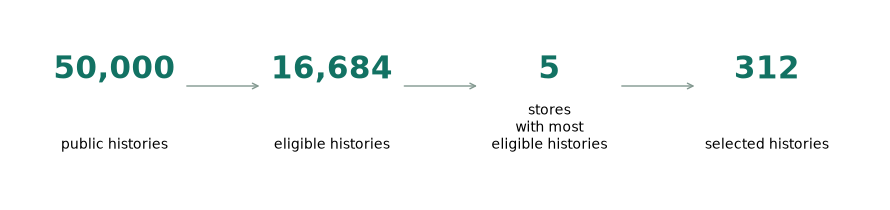

In [2]:
funnel = evidence["selection_funnel"]
display(pd.DataFrame([
    ["Public training histories", funnel["all_series"]],
    ["Keep 15%–85% discounted days", funnel["after_discount_share_filter"]],
    ["Also require at least six state switches", funnel["after_discount_share_and_switch_filters"]],
    ["Also require fewer than 20% zero-sales days", funnel["after_all_three_filters"]],
    ["Eligible histories in the selected five stores", funnel["selected_series_in_top_five"]],
], columns=["Selection stage", "Store-product series"]))
stores = pd.DataFrame(funnel["top_five_stores_ranked"])
display(stores[["store_id", "city_id", "n_eligible"]].rename(columns={
    "store_id": "Store ID", "city_id": "City ID", "n_eligible": "Eligible products"}))
print("Distinct products across these stores:", funnel["selected_unique_products"])
assert len(feat[C.KEY].drop_duplicates()) == funnel["selected_series_in_top_five"]
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis("off")
steps = [("50,000", "public histories"),
         (f'{funnel["after_all_three_filters"]:,}', "eligible histories"),
         ("5", "stores with most eligible histories"), ("312", "selected histories")]
for i, (count, label) in enumerate(steps):
    x = .12 + i*.25
    ax.text(x, .64, count, ha="center", fontsize=22, color="#127263", fontweight="bold")
    ax.text(x, .27, label.replace(" with most ", "\nwith most\n"), ha="center", fontsize=10)
    if i < 3:
        ax.annotate("", xy=(x+.17,.6), xytext=(x+.08,.6), arrowprops={"arrowstyle":"->", "color":"#82988f"})
fig.tight_layout(); plt.show()

The result is **312 store-product histories involving 122 different products**. This keeps comparisons
manageable and gives each retained series some recorded discount variation. It does not make discounts
random, or make these stores representative of all fresh-food retailers.

There is also a selection limitation: these rules use the entire original 90-day training file, including
dates later than the first validation week. This is a retrospective working cohort. A stricter future
study should choose the cohort before the first validation period, or repeat selection inside each
training fold. We keep this same cohort here so the teammate and Lisa comparisons use the same cases.

## 4. Turn the business question into one prediction

Imagine standing at the end of today with a particular store-product's record. We know how it sold
recently, whether stock was unavailable, which discount was used, and tomorrow's calendar. We also
have a candidate discount that the manager could choose. What we do not know is tomorrow's sales.

**Our prediction target, Y, is next-day normalized observed sales.** The discount is an input to the
prediction, not the target. At this stage we learn to forecast sales under recorded conditions; the
later decision step will replace that price input with alternative candidates.

| Information available by the decision time | Role in the forecast |
|---|---|
| Yesterday's sales, same weekday last week, recent sales averages | Describe the recent level and pattern of sales |
| Yesterday's discount, stockout hours and activity | Describe recent trading and availability |
| Tomorrow's weekday, holiday status and proposed discount | Describe the day being forecast and the proposed action |
| Tomorrow's actual sales or actual stockouts | Excluded from the predictors; these happen after the decision |

The example below is the first final-period row in store-product-date order. Its observed outcome is
shown only so that we can check the forecast afterwards. The dataset does not give this anonymized
product a name, so we keep its identifier rather than inventing a product story.

In [3]:
example = feat[feat.split == "test"].sort_values(C.ROW_KEY).iloc[[0]]
case_key = example.iloc[0]
readable = {
    "Store": case_key.store_id, "Product": case_key.product_id,
    "Day being predicted": str(case_key["dt"].date()),
    "Yesterday's sales": case_key.sales_t, "Previous 7-day average": case_key.sales_mean7,
    "Yesterday's stockout hours": case_key.stockout_hours_t,
    "Recorded target-day price rate": case_key.discount_next,
    "Actual target-day sales (evaluation only)": case_key[C.TARGET],
}
display(pd.DataFrame(readable.items(), columns=["Case information", "Value"]))

,Case information,Value
0,Store,18
1,Product,11
2,Day being predicted,2024-06-26
3,Yesterday's sales,1.4
4,Previous 7-day average,1.25714
5,Yesterday's stockout hours,0.0
6,Recorded target-day price rate,0.989
7,Actual target-day sales (evaluation only),0.6


The date attached to each feature row is the day being predicted. Historical windows end before that
date: the seven-day mean, for example, uses the seven preceding days. The selected raw records have no
invalid price-rate or missing-value removals; the first seven days of each series are dropped to build
complete lag histories. This leaves 25,896 training-period rows and 2,184 final-period rows. Every model
is evaluated on the same rows. The target is copied from the source's normalized sales field; this project
does not normalize it a second time.

In a daily workflow, yesterday's observed sales become available before predicting today. We therefore
make rolling one-day-ahead forecasts, updating the history within each evaluation week while keeping
the model fitted at that week's start. This does not claim to forecast a whole week before any of it occurs.

## 5. Start with a decision a manager could make without ML

Before fitting a complex model, consider a simple forecast: **tomorrow will sell about as much as the
average of the previous seven days**. A second baseline reuses sales from the same weekday last week.
If machine learning cannot improve on these, extra complexity has little forecasting justification.

We use mean absolute error, or **MAE**, as the primary score: the average size of a forecast miss.
Lower is better. RMSE gives greater weight to large misses, so we keep it as a second check rather than
assuming that the lowest MAE means every kind of error improved.

To resemble predicting the future, we compare on later dates. Each of five weekly validation rounds
trains on all earlier available feature rows. The mean validation MAE selects the model; the final week
then provides a common benchmark. Preprocessing is fitted within each training fold.

**A limit we carry throughout:** these weeks have been used in earlier project development. The final
week is an already-viewed benchmark, not an untouched holdout. Recording the new selection before
its final scoring prevents new choices within this run, but cannot undo earlier exposure.

In [4]:
display(pd.DataFrame([
    {"Round": k, "Train on": "All feature dates before " + dates[0],
     "Validate from": dates[0], "Validate through": dates[1]}
    for k, dates in plan["folds"].items()]))
display(comparison[comparison.model.isin(["7-day mean", "Same weekday"])][
    ["model", "validation_mae", "test_mae", "test_rmse"]].rename(columns={"test_mae":"final_period_mae", "test_rmse":"final_period_rmse"}))

,Round,Train on,Validate from,Validate through
0,1,All feature dates before 2024-05-22,2024-05-22,2024-05-28
1,2,All feature dates before 2024-05-29,2024-05-29,2024-06-04
2,3,All feature dates before 2024-06-05,2024-06-05,2024-06-11
3,4,All feature dates before 2024-06-12,2024-06-12,2024-06-18
4,5,All feature dates before 2024-06-19,2024-06-19,2024-06-25


,model,validation_mae,final_period_mae,final_period_rmse
0,7-day mean,0.32840,0.31418,0.52089
1,Same weekday,0.41502,0.39975,0.61707


The recent seven-day mean is the stronger baseline here. We use it as the main reference while continuing
to report both. The next question is whether the discount and context inputs add enough information to
improve on that recent-sales average.

## 6. What the teammate's work established

Aashish's notebook develops this question through k-nearest neighbours, Random Forest and CatBoost,
then a blend of the two tree models. Each model offers a different way to learn from comparable past
cases. The point of the comparison is to find out which added complexity is useful on the same later dates.

| Method | The plain-language idea | Why include it? |
|---|---|---|
| k-nearest neighbours | Find similar past trading days and average their sales | An intuitive reference for learning from comparable cases |
| Random Forest | Average many trees that divide trading conditions into groups | Capture nonlinear relationships and reduce reliance on a single tree |
| CatBoost | Add small trees sequentially to improve the current prediction | Test whether correcting earlier errors helps |
| A 50/50 blend | Average the forest and CatBoost predictions | Test whether their errors offset each other |

The teammate also documented tuning choices and found that weather did not improve his validation
results. We inherit his ten-input reference design and its settings. This narrative revision does not
claim to rerun or rediscover every earlier tuning experiment. The table below comes from the matched
V2 experiment, which refitted those reference designs alongside the extension.

In [5]:
reference_names = ["7-day mean", "Same weekday", "kNN reference", "Teammate RF", "Teammate CatBoost", "Teammate blend 50/50"]
display(metrics.loc[reference_names, ["validation_mae", "test_mae", "test_rmse"]].rename(
    columns={"test_mae":"final_period_mae", "test_rmse":"final_period_rmse"}))

,validation_mae,final_period_mae,final_period_rmse
model,,,
7-day mean,0.32840,0.31418,0.52089
Same weekday,0.41502,0.39975,0.61707
kNN reference,0.31198,0.30398,0.49002
Teammate RF,0.30244,0.29235,0.46459
Teammate CatBoost,0.30330,0.28965,0.46026
Teammate blend 50/50,0.30125,0.28923,0.45926


All four learned reference methods improve on the seven-day average in this comparison. The blend's
advantage over its individual tree models is small. That suggests a useful next question for Lisa's
extension: can a better description of recent trading, and a training objective aligned with our chosen
error metric, help more than simply adding another model?

## 7. Lisa's extension: give the model a better account of recent trading

Two products can have the same seven-day average but very different recent paths: one may be rising,
the other falling. A stable series and an erratic series can also share the same average. We add past-only
features to make these differences visible, together with store and product identifiers treated as categories.

| Proposed change | Reason to test it | How we interpret the evidence |
|---|---|---|
| More recent history and variation | Distinguish short-term direction, variability and longer-running level | The feature/ID package changes several things together; its comparison also changes regularization, so individual effects are not isolated |
| Train CatBoost with MAE loss | Align training more closely with the primary selection metric | Compare RMSE and MAE loss with the same extended inputs and other CatBoost settings |
| Blend the best standalone design with RF | Let different prediction errors partly offset | Compare three declared RF weights using validation MAE |

The additions include sales two and three days ago, averages over three and fourteen days, seven-day
variation, a short-versus-long recent trend, previous discount averages and recent stockout-day counts.
They use only earlier observations. There are 18 numeric inputs plus two categorical IDs in the extended design.

The bounded experiment contains eleven standalone designs, four blends and two baselines. The familiar
Ridge, decision tree and HistGradientBoosting models remain in the comparison; the full table is in the
appendix. Candidates and blend rules were recorded before this run's final-period scoring.

We first ask a controlled question: when the extended CatBoost inputs and other settings are unchanged,
does MAE training improve average absolute error, and what happens to large errors?

In [6]:
loss_rows = ["CatBoost history + IDs", "CatBoost history + IDs MAE"]
display(metrics.loc[loss_rows, ["validation_mae", "test_mae", "test_rmse"]].rename(
    columns={"test_mae":"final_period_mae", "test_rmse":"final_period_rmse"}))

,validation_mae,final_period_mae,final_period_rmse
model,,,
CatBoost history + IDs,0.29715,0.28423,0.45500
CatBoost history + IDs MAE,0.29449,0.28458,0.46006


MAE training improves validation MAE in this controlled comparison, so it is the stronger standalone
candidate under our selection rule. Yet its final-period MAE and RMSE are worse than the RMSE-trained
extended version. This is why we specify the selection criterion first and show secondary outcomes
rather than treating every change as an improvement.

MAE training estimates a conditional median. Later, when we multiply its forecast by a price rate, that
product will be a decision proxy, not a claim about mathematically expected revenue.

## 8. Did the extension improve the forecast?

The validation rule selects a blend of **25% Random Forest and 75% extended CatBoost trained with MAE**.
Those weights combine two forecasts; they are not a 25% or 75% discount on a product.

We now compare it with the baselines and the teammate's blend on the same cases. This is the answer to
the forecasting part of the project, before making any claim about a pricing policy.

,validation_mae,final_period_mae,final_period_rmse
model,,,
7-day mean,0.32840,0.31418,0.52089
Same weekday,0.41502,0.39975,0.61707
Teammate blend 50/50,0.30125,0.28923,0.45926
RF + validation best (25/75),0.29402,0.28339,0.45605


Final-period MAE reduction versus 7-day mean: 9.80%
Final-period MAE reduction versus Teammate blend 50/50: 2.02%
Validation weeks better than the teammate blend: 5 out of 5


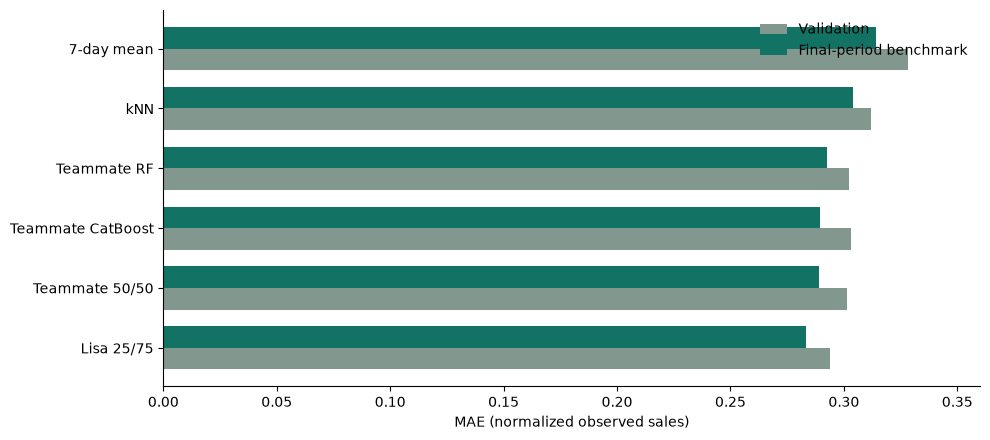

In [7]:
show = ["7-day mean", "Same weekday", "Teammate blend 50/50", winner]
display(metrics.loc[show, ["validation_mae", "test_mae", "test_rmse"]].rename(
    columns={"test_mae":"final_period_mae", "test_rmse":"final_period_rmse"}))
folds = pd.read_csv(OUT / "validation_folds.csv")
paired = folds[folds.model.isin(["Teammate blend 50/50", winner])].pivot(index="fold", columns="model", values="mae")
for ref in ["7-day mean", "Teammate blend 50/50"]:
    improvement = 100*(metrics.loc[ref,"test_mae"]-metrics.loc[winner,"test_mae"])/metrics.loc[ref,"test_mae"]
    print(f"Final-period MAE reduction versus {ref}: {improvement:.2f}%")
print("Validation weeks better than the teammate blend:", int((paired[winner] < paired["Teammate blend 50/50"]).sum()), "out of 5")
plot_names = ["7-day mean", "kNN reference", "Teammate RF", "Teammate CatBoost", "Teammate blend 50/50", winner]
fig, ax = plt.subplots(figsize=(10, 4.5)); pos = np.arange(len(plot_names)); width = .36
ax.barh(pos+width/2, metrics.loc[plot_names,"validation_mae"], width, label="Validation", color="#82988f")
ax.barh(pos-width/2, metrics.loc[plot_names,"test_mae"], width, label="Final-period benchmark", color="#127263")
ax.set_yticks(pos, ["7-day mean", "kNN", "Teammate RF", "Teammate CatBoost", "Teammate 50/50", "Lisa 25/75"])
ax.invert_yaxis(); ax.set_xlim(0,.36); ax.set_xlabel("MAE (normalized observed sales)")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

The selected blend has lower MAE than the teammate's blend in all five validation weeks and improves
final-period MAE by about 2%. That is a modest, measured gain within this cohort. It does not establish
that the weights are universally optimal, or that every metric, product or future store improves.

Before handing this forecast to a manager, we need to examine where it still misses and what happens
when we actually ask it to choose a discount.

## 9. Look at the mistakes before trusting the recommendation

Average error can hide the cases a manager cares about most. Deep discounts coincide with larger sales
spikes and are harder to forecast here. We inspect every recorded discount band, rather than selecting
only the band in which a model looks good. We also show the largest misses, chosen mechanically by
absolute error.

Target-day stockouts may help explain a miss after the fact. They are used for diagnosis only and are
never given to the model before its forecast.

In [8]:
slices = pd.read_csv(OUT / "error_slices.csv")
display(slices[slices["slice"] == "discount"][["value","model","mae","rmse","n"]])
largest = pd.read_csv(OUT / "largest_errors.csv")
display(largest[C.ROW_KEY + [C.TARGET,"discount_next","target_stockout_hours",winner,"selected_abs_error"]].head(3))

,value,model,mae,rmse,n
36,none_or_small,7-day mean,0.27105,0.39351,1186
37,none_or_small,Teammate blend 50/50,0.23298,0.32635,1186
38,none_or_small,RF + validation best (25/75),0.22907,0.32248,1186
39,moderate,7-day mean,0.30332,0.44538,757
40,moderate,Teammate blend 50/50,0.29821,0.43218,757
41,moderate,RF + validation best (25/75),0.29278,0.43624,757
42,deep,7-day mean,0.56059,1.03619,241
43,deep,Teammate blend 50/50,0.53784,0.89476,241
44,deep,RF + validation best (25/75),0.52122,0.88049,241


,store_id,product_id,dt,target_sales,discount_next,target_stockout_hours,RF + validation best (25/75),selected_abs_error
0,343,38,2024-06-29,10.3,0.505,9,4.73391,5.56609
1,343,122,2024-06-30,10.6,0.633,0,6.48249,4.11751
2,18,122,2024-06-30,10.1,0.633,0,6.11697,3.98303


These errors matter because a recommendation based on an understated sales spike or censored history
can be misleading. A model that wins on average still needs decision checks. The next step exposes a
second problem: predicting recorded sales and choosing a new price are different tasks.

## 10. The turning point: a good forecaster can still over-recommend discounts

To compare prices, we hold the known context fixed and change only tomorrow's candidate discount.
The menu includes full price, 5% off, 10% off and deeper reductions. Each candidate receives a sales
forecast. Selecting the candidate with the highest forecast sounds natural if the goal is to sell more.

But a model can learn that deep-discount days have high sales without learning that a deep discount
would cause high sales on an ordinary day. Managers chose historical discounts for reasons that are
not all in the dataset. Simply setting a different price input does not remove that selection problem.

This was a central finding in the teammate's storyline. The table below repeats the diagnostic using
**Lisa's already-saved candidate forecasts**, without refitting models or observing any new sales.
It compares choosing the largest forecast with choosing the largest price-rate-times-forecast proxy,
both before and after requiring historical price support. The manager-review rules have not yet been applied.

In [9]:
naive_rows = []
for supported_only in [False, True]:
    pool = responses[responses.supported].copy() if supported_only else responses.copy()
    pool["value_proxy"] = pool.rate * pool.selected_sales
    for criterion in ["selected_sales", "value_proxy"]:
        # Highest rate first gives a milder discount if forecasts tie exactly.
        ordered = pool.sort_values(C.ROW_KEY + [criterion,"rate"], ascending=[True]*len(C.ROW_KEY)+[False,False])
        chosen = ordered.drop_duplicates(C.ROW_KEY)
        naive_rows.append({"Search": "Historically supported rates" if supported_only else "All candidate rates",
            "Choose highest": "Forecast sales" if criterion == "selected_sales" else "Sales-value proxy",
            "Cases": len(chosen), "Discount recommended (%)": round(100*(chosen.rate<1).mean(),1),
            "Choices without support": int((~chosen.supported).sum())})
display(pd.DataFrame(naive_rows))

,Search,Choose highest,Cases,Discount recommended (%),Choices without support
0,All candidate rates,Forecast sales,2184,100.0,2062
1,All candidate rates,Sales-value proxy,2184,99.8,1816
2,Historically supported rates,Forecast sales,2184,100.0,0
3,Historically supported rates,Sales-value proxy,2184,99.4,0


Historical support limits where the model extrapolates, but does not by itself settle whether a discount
is justified. We therefore treat the prediction as an input to a transparent decision process, not as
a direct instruction to the manager. Even that process will remain provisional until business outcomes
under the recommended policy can be observed.

## 11. From a sales forecast to a specific discount

The manager needs an answer such as **10% off**, not just a forecast number. The extension uses the
following sequence to decide when it can offer that answer.

| Step | Decision and reason |
|---|---|
| Check supply | A stockout yesterday triggers review: sales may have been censored and tomorrow's availability needs checking |
| Check relevant history | Require at least three training days within ±0.025 of each candidate rate, plus a supported full-price comparator |
| Check the trade-off | Require at least 5% predicted sales gain and at least 95% of the full-price sales-value proxy |
| Check model agreement | The selected blend and both reference models must independently pass those same comparisons |
| Choose the depth | Among passing candidates, find the highest predicted sales; choose the mildest discount within 1% of that best forecast |

The sales-value proxy is **price rate × predicted normalized sales**. It allows a relative comparison
for the same product, but is not money or profit. The thresholds are illustrative business choices,
not values learned to be optimal. Model agreement is a sensitivity check, not a calibrated confidence interval.

This also explains what we changed in the teammate's stock rules. A stockout does not prove tomorrow's
stock is fresh, and a week without a stockout does not prove the stock is a week old. We request a supply
review when necessary and do not infer inventory age from these signals.

## 12. Follow one real case to a 10% discount

We use the **first supported recommendation in store-product-date order**, not the case with the
largest predicted gain: store 18, product 11, on 26 June 2024. This is the same case introduced earlier.
Its previous-day stockout hours are zero, so it passes the initial supply-review check.

Read the following table as a set of alternatives for that one day. A price rate of 0.90 means **10% off**
(九折). Only the recorded rate has an actual sales outcome; the alternative forecasts are scenarios.

,Price rate,Nearby historical days,Predicted sales,Predicted gain (%),Selected value / full price,RF value / full price,Decision
0,1.00,33,1.07370,0.00000,1.00000,1.00000,Full-price comparator
1,0.95,10,1.24016,15.50412,1.09729,1.02956,Passes; lower forecast sales
2,0.90,12,1.29123,20.26016,1.08234,0.98412,Selected
3,0.85,23,1.38568,29.05702,1.09698,0.94597,Fails at least one model's gain/value check
4,0.80,5,1.43157,33.33119,1.06665,0.93669,Fails at least one model's gain/value check
5,0.75,0,1.47889,37.73783,1.03303,0.89711,Too little nearby price history
6,0.70,0,1.71976,60.17197,1.12120,0.90256,Too little nearby price history
7,0.60,0,1.92641,79.41871,1.07651,0.80946,Too little nearby price history


Recommendation: 10% off; predicted sales 1.291.


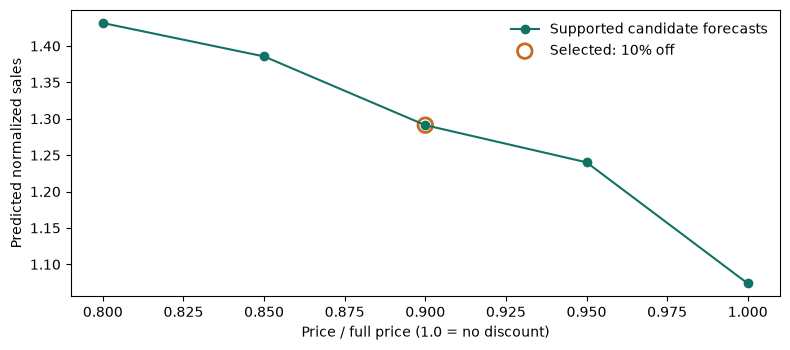

In [10]:
case = recs[recs.status == "recommend_discount"].sort_values(C.ROW_KEY).iloc[0]
mask = (responses.store_id == case.store_id) & (responses.product_id == case.product_id) & (responses.dt == case["dt"])
case_curve = responses.loc[mask].sort_values("rate", ascending=False).copy()
full = case_curve[case_curve.rate == 1.].iloc[0]
settings = plan["decision_parameters"]
case_curve["selected_gain_pct"] = 100*(case_curve.selected_sales/full.selected_sales-1)
case_curve["selected_value_share"] = case_curve.rate*case_curve.selected_sales/full.selected_sales
case_curve["rf_value_share"] = case_curve.rate*case_curve.rf_sales/full.rf_sales
case_curve["passes_all_models"] = case_curve.supported & (case_curve.rate < 1)
for col in ["selected_sales","rf_sales","cat_sales"]:
    case_curve["passes_all_models"] &= (case_curve[col]/full[col]-1 >= settings["min_sales_gain"])
    case_curve["passes_all_models"] &= (case_curve.rate*case_curve[col]/full[col] >= settings["min_value_share"])
def explain(row):
    if row.rate == 1: return "Full-price comparator"
    if not row.supported: return "Too little nearby price history"
    if not row.passes_all_models: return "Fails at least one model's gain/value check"
    return "Selected" if np.isclose(row.rate,case.recommended_rate) else "Passes; lower forecast sales"
case_curve["Decision"] = case_curve.apply(explain,axis=1)
display(case_curve[["rate","support_days","selected_sales","selected_gain_pct","selected_value_share","rf_value_share","Decision"]].rename(columns={
    "rate":"Price rate", "support_days":"Nearby historical days", "selected_sales":"Predicted sales",
    "selected_gain_pct":"Predicted gain (%)", "selected_value_share":"Selected value / full price",
    "rf_value_share":"RF value / full price"}).reset_index(drop=True))
print(f"Recommendation: {100*(1-case.recommended_rate):.0f}% off; predicted sales {case.predicted_sales:.3f}.")
fig, ax = plt.subplots(figsize=(8,3.6)); supported = case_curve[case_curve.supported]
ax.plot(supported.rate,supported.selected_sales,"o-",color="#127263",label="Supported candidate forecasts")
ax.scatter([case.recommended_rate],[case.predicted_sales],s=110,facecolors="none",edgecolors="#c76a20",linewidths=2,label="Selected: 10% off")
ax.set_xlabel("Price / full price (1.0 = no discount)"); ax.set_ylabel("Predicted normalized sales")
ax.legend(frameon=False); fig.tight_layout(); plt.show()

Why stop at 10% off when 15% or 20% off predicts more sales? In this case, the Random Forest reference
puts those deeper candidates below the required 95% of full-price value. They therefore fail the
agreement rule. Still deeper candidates lack enough nearby historical price observations. Both 5% and
10% off pass, and 10% off has the higher selected sales forecast by more than the near-tie allowance.

This is a concrete recommendation with a traceable reason. It is **not proof that nine-tenths of full
price is the true optimal price**. For this day, the observed sales record belongs to the actual recorded
rate, not to every alternative in the table.

## 13. A useful assistant must also know when to defer

The next table shows the first case, again by key order, where previous-day stockouts require a supply
review. Giving that case an explicit reason is preferable to silently dropping it or pretending to know
how old the inventory is.

In [11]:
display(recs[recs.status == "review_stockout"].sort_values(C.ROW_KEY)[C.ROW_KEY+["status","reason"]].head(1))
counts = pd.DataFrame(policy["status_counts"].items(),columns=["Decision", "Cases"])
counts["Share (%)"] = 100*counts.Cases/policy["rows"]
display(counts)
no_stockout = feat[feat.split == "test"][C.ROW_KEY+["stockout_hours_t"]].merge(recs,on=C.ROW_KEY,validate="one_to_one")
no_stockout = no_stockout[no_stockout.stockout_hours_t < settings["stockout_hours_review_threshold"]]
print(f"All {len(recs):,} input cases receive an explicit output.")
print(f"Automatic decision coverage: {policy['decision_coverage']:.1%}")
print(f"Among {len(no_stockout):,} cases without yesterday's stockout, {(no_stockout.status == 'recommend_discount').mean():.1%} still recommend a discount.")

,store_id,product_id,dt,status,reason
2,18,11,2024-06-28,review_stockout,Recent censored sales; verify tomorrow's suppl...


,Decision,Cases,Share (%)
0,recommend_discount,1179,53.98352
1,review_stockout,967,44.27656
2,review_model_disagreement,38,1.73993


All 2,184 input cases receive an explicit output.
Automatic decision coverage: 54.0%
Among 1,217 cases without yesterday's stockout, 96.9% still recommend a discount.


The checks produce a recommendation on about 54% of all cases and a review on the remainder. Complete
output coverage is not the same as automatic decision coverage.

There is a substantial unresolved weakness: **96.9% of cases without a previous-day stockout still
receive a discount recommendation**, and none of the current cases select keep-full-price. The rules
make the process more explicit, but have not established that it reliably identifies days when a
discount is genuinely beneficial. Agreement among models trained on similar observational data can
preserve the same bias.

## 14. The improvement has a boundary: other stores

The original five stores share one city. After locking the selected model, we asked whether it would
also help elsewhere. A fixed ordering of eligible training-data keys selected 100 series outside city 0.
The models were still trained only on the original cohort; no new-store outcomes were used for tuning.
Earlier daily observations from those new stores supplied their lag inputs, as required for daily prediction.

This check covers 700 evaluation rows in 93 new stores across 16 other cities, including 47 product IDs
not seen by the fitted models. It is a transfer stress test, not a claim that no group member ever viewed
these public records during the project's history.

In [12]:
transfer_dir = ROOT / "results" / "v2_transfer"
display(pd.read_csv(transfer_dir/"summary.csv")[["model","mae","rmse","rows"]])

,model,mae,rmse,rows
0,7-day mean,0.29667,0.48356,700
1,Same weekday,0.36263,0.57550,700
2,Teammate blend 50/50,0.28842,0.47096,700
3,RF + validation best (25/75),0.28902,0.48863,700


The new blend does **not** beat the teammate's blend in this check. Its RMSE is also worse than the
seven-day mean. We keep the original validation-selected design and report the failure rather than
switching models after seeing these outcomes. The current evidence supports a modest forecasting
improvement in the original cohort, not a broadly superior fresh-food pricing system.

## 15. What the manager can take away

We have a reproducible way to turn recent observations into a sales forecast, compare supported price
scenarios, and explain a specific discount or review decision. The extension improves the original-cohort
forecast and makes the decision checks traceable. It also exposes why that is only part of the business problem.

A real pilot would need reliable availability, replenishment, expiry and cost information. It would also
need prospective evidence, such as an appropriately designed pricing experiment, to estimate what the
recommended discounts actually change. We cannot infer realized profit or waste reduction from these
forecast errors or hypothetical response curves.

The contribution is therefore a tested forecasting comparison and a transparent decision-support prototype,
with a worked example recommending 10% off and documented failure cases. A manager can inspect its reasoning;
the present evidence does not justify automatically rolling it out to every store.

The narrative follows Aashish's progression from forecasting to a discount what-if. Lisa's separate extension
adds history and ID features, the controlled loss comparison, a bounded blend comparison, explicit review
outputs and the transfer check. The original notebook and helper modules remain available and credited.

## Technical appendix A. How the model produces a number

The main story can be read without the following mechanics. They are included so the recommendation
can be explained and reproduced during the demonstration.

For one input row $x$, a Random Forest averages predictions from bootstrap-trained decision trees.
Each tree uses feature thresholds to reach a leaf; its leaf prediction is a training-target average.
CatBoost adds trees sequentially: $F_m(x)=F_{m-1}(x)+\eta h_m(x)$, where $F_m$ is the prediction after
step $m$, $h_m$ is the next tree, and $\eta$ is the learning rate. Its categorical machinery handles store
and product IDs as categories in the extended design.

The selected forecast is $\hat y=w\hat y_{RF}+(1-w)\hat y_{CB}$, where $w=0.25$, $\hat y_{RF}$ is the
forest forecast and $\hat y_{CB}$ the extended CatBoost forecast. The forecast concerns normalized
observed sales. MAE training targets a conditional median rather than an expected-demand guarantee.

Below we refit only those two already-selected members on the original training feature rows. We show
their predictions for the earlier real case at its recorded price, the blend arithmetic and the first
forest tree's actual path. This example uses the included feature table and needs no full raw-data download.

In [13]:
training = feat[feat.split == "train"]
specs = {s["name"]: s for s in plan["candidates"]}
members = selection["blend_weights"].get(winner,{winner:1.})
live_models = {}; example_values = []
from threadpoolctl import threadpool_limits
for name, weight in members.items():
    spec = specs[name]
    with threadpool_limits(limits=4):
        model = v2.estimator(spec).fit(training[v2.columns(spec)],training[C.TARGET])
    live_models[name] = model
    prediction = float(v2.predict(model,example,spec)[0])
    example_values.append({"Member":name,"Weight":weight,"Prediction":prediction,"Weighted part":weight*prediction})
example_table = pd.DataFrame(example_values); display(example_table)
live_prediction = example_table["Weighted part"].sum()
saved_case = test_predictions[(test_predictions.store_id == case_key.store_id) &
    (test_predictions.product_id == case_key.product_id) & (test_predictions.dt == case_key["dt"])].iloc[0]
print(f"Blend: {live_prediction:.6f}; observed outcome: {case_key[C.TARGET]:.6f}")
print("Replay difference from saved forecast:",abs(live_prediction-saved_case[winner]))
assert np.isclose(live_prediction,saved_case[winner],atol=1e-6)
forest = live_models.get("Teammate RF")
if forest is not None:
    x = example[C.FEATURES].to_numpy(); tree = forest.estimators_[0]; leaf = tree.apply(x)[0]
    print("First forest tree's leaf prediction:",float(tree.tree_.value[leaf,0,0]))
    print("Forest mean across",len(forest.estimators_),"trees:",float(np.mean([t.predict(x)[0] for t in forest.estimators_])))
    for node in tree.decision_path(x).indices:
        feature = tree.tree_.feature[node]
        if feature >= 0:
            value, threshold = x[0,feature],tree.tree_.threshold[node]
            print(f"{C.FEATURES[feature]} = {value:.4f} {'<=' if value <= threshold else '>'} {threshold:.4f}")

,Member,Weight,Prediction,Weighted part
0,Teammate RF,0.25,1.24649,0.31162
1,CatBoost history + IDs MAE,0.75,1.20780,0.90585


Blend: 1.217470; observed outcome: 0.600000
Replay difference from saved forecast: 0.0
First forest tree's leaf prediction: 1.1382456140350878
Forest mean across 300 trees: 1.2464884870414898
sales_mean7 = 1.2571 <= 1.7500
sales_mean7 = 1.2571 > 0.8493
discount_next = 0.9890 > 0.5550
discount_next = 0.9890 <= 0.9990
sales_mean7 = 1.2571 > 1.1364
weekday_next = 2.0000 <= 4.5000
discount_next = 0.9890 > 0.7230
sales_lag7 = 2.0000 > 1.7500
sales_mean7 = 1.2571 <= 1.5643
sales_mean_to_date = 1.1756 <= 1.1924


## Technical appendix B. Metrics, inputs and the full comparison

For $n$ evaluated rows with observed sales $y_i$ and forecasts $\hat y_i$:

$$MAE=\frac1n\sum_i|y_i-\hat y_i|,\qquad RMSE=\sqrt{\frac1n\sum_i(y_i-\hat y_i)^2}.$$

WAPE is $\sum_i|y_i-\hat y_i|/\sum_i|y_i|$. Lower is better. Validation MAE selects the design;
RMSE and WAPE provide additional error perspectives. The full comparison below retains both baselines first.

Rolling features are shifted before aggregation, so they exclude the target day's sales. The ten base
inputs match the teammate implementation, including **yesterday's** activity flag. The older main-branch
implementation instead used target-day planned activity; identical baseline scores do not establish
identical input definitions.

In [14]:
display(comparison[["model","validation_mae","test_mae","test_rmse","test_wape","selected"]])
display(pd.DataFrame({"Group":["Base"]*len(C.FEATURES)+["Additional history"]*len(v2.EXTRA)+["Categorical ID"]*len(v2.IDS),
                      "Feature":C.FEATURES+v2.EXTRA+v2.IDS}))
display(pd.DataFrame(plan["candidates"]).fillna("—"))
display(paired)

,model,validation_mae,test_mae,test_rmse,test_wape,selected
0,7-day mean,0.32840,0.31418,0.52089,0.32436,False
1,Same weekday,0.41502,0.39975,0.61707,0.41270,False
2,Ridge,0.31553,0.30725,0.50280,0.31720,False
3,Decision tree,0.32359,0.32222,0.49868,0.33266,False
4,HistGradientBoosting,0.30585,0.29006,0.45692,0.29945,False
5,kNN reference,0.31198,0.30398,0.49002,0.31383,False
6,Teammate RF,0.30244,0.29235,0.46459,0.30182,False
7,Teammate CatBoost,0.30330,0.28965,0.46026,0.29903,False
8,Main CatBoost,0.30355,0.28754,0.45110,0.29685,False
9,CatBoost MAE,0.30273,0.28844,0.46459,0.29778,False


,Group,Feature
0,Base,sales_t
1,Base,sales_lag7
2,Base,sales_mean7
3,Base,sales_mean_to_date
4,Base,stockout_hours_t
5,Base,discount_t
6,Base,discount_next
7,Base,activity_t
8,Base,holiday_next
9,Base,weekday_next


,name,kind,features,alpha,depth,leaf,monotonic,iterations,lr,loss,l2
0,Ridge,ridge,base,10.0,—,—,—,—,—,—,—
1,Decision tree,tree,base,—,6.0,20.0,—,—,—,—,—
2,HistGradientBoosting,hist,base,—,—,—,False,—,—,—,—
3,kNN reference,knn,base,—,—,—,—,—,—,—,—
4,Teammate RF,rf,base,—,—,—,—,—,—,—,—
5,Teammate CatBoost,cat,base,—,5.0,—,—,500.0,0.03,RMSE,3.0
6,Main CatBoost,cat,base,—,4.0,—,—,400.0,0.05,RMSE,5.0
7,CatBoost MAE,cat,base,—,5.0,—,—,500.0,0.03,MAE,3.0
8,CatBoost history + IDs,cat,history_ids,—,5.0,—,—,500.0,0.03,RMSE,5.0
9,CatBoost history + IDs MAE,cat,history_ids,—,5.0,—,—,500.0,0.03,MAE,5.0


model,RF + validation best (25/75),Teammate blend 50/50
fold,,
1,0.28155,0.28759
2,0.28126,0.29022
3,0.32512,0.33419
4,0.27917,0.29023
5,0.30299,0.30404


Ridge uses standardized numeric inputs with a coefficient penalty. The single decision tree is a simple
nonlinear reference. HistGradientBoosting tests another sequential tree approach, including a variant
with a monotonic price-rate constraint. kNN scales inputs within each training fold before finding nearby
training cases. The model factories preserve the declared settings; there is no fresh parameter search
inside this narrative notebook.

The paired bootstrap analysis below resamples store-product series, keeping each series' seven final
observations together. It is descriptive: shared-store shocks and repeated model-selection optimism are
not corrected. Five stores and one week are too little to establish broad reliability.

In [15]:
display(json.loads((OUT/"paired_comparison.json").read_text()))
display(slices[(slices["slice"] == "store") & (slices.model == winner)][["value","mae","rmse","n"]])

{'selected_minus_teammate_mae': -0.005842771261994179,
 'series_bootstrap_95pct_interval': [-0.010104686129866775,
  -0.0011266001930648228],
 'limitation': 'Descriptive 7-day, 5-store interval; shared-store correlation and selection optimism not corrected.'}

,value,mae,rmse,n
23,18,0.28720,0.45645,448
26,154,0.24521,0.35712,420
29,182,0.29080,0.46107,427
32,235,0.26912,0.38771,441
35,343,0.32235,0.57915,448


## Technical appendix C. Reproduce the evidence

This is a narrative revision of the saved experiment, not a new tuning round. The forecast target,
cohort, fitted-design selection and reported benchmark scores are unchanged. The selection-funnel
artifact can be rebuilt from the verified public raw files with `scripts/build_story_evidence.py`.
The default notebook reads saved evidence and performs only the two live worked-example fits above.

From a complete repository copy:
```bash
docker compose up --build -d
docker compose exec lab python scripts/jupyter_v2_url.py
docker compose exec lab python scripts/run_v2.py --verify-only
docker compose exec lab python scripts/execute_lisa_notebook.py
```

To regenerate the complete experiment and story evidence:
```bash
docker compose exec lab python scripts/download_public_data.py
docker compose exec lab python scripts/run_v2.py
docker compose exec lab python scripts/run_v2_transfer_check.py --force
docker compose exec lab python scripts/build_story_evidence.py
docker compose exec lab python scripts/build_lisa_notebook.py
docker compose exec lab python scripts/execute_lisa_notebook.py
```

The raw files are downloaded once and reused after verification. Building the image initially needs
network access; the saved-data demonstration runs offline. The report and lab use separate image snapshots:
export changes made inside the lab container before recreating it, and rebuild the report image to show
regenerated output. The README contains the complete export and data-volume instructions.

In [16]:
display(pd.DataFrame(plan["environment"].items(),columns=["Package","Recorded experiment version"]))
print("Saved experiment verification:",verification["status"])
print("Feature rows:",len(feat),"; validation predictions:",verification["oof_rows"],"; final-period cases:",verification["test_rows"])
print("Selection was recorded before this run's final scoring:",selection["selected_before_test_scoring_utc"])
print("Original full experiment fits:",json.loads((OUT/"run_receipt.json").read_text()).get("fitted_models"))

,Package,Recorded experiment version
0,python,3.12.13
1,numpy,2.5.3
2,pandas,3.0.6
3,scikit-learn,1.9.1
4,catboost,1.2.10
5,pyarrow,25.0.1


Saved experiment verification: passed
Feature rows: 28080 ; validation predictions: 10920 ; final-period cases: 2184
Selection was recorded before this run's final scoring: 2026-10-09T17:48:26.124294+00:00
Original full experiment fits: 66


The supplied brief requires each member's factual contribution and generative-AI declaration. See
`docs/CONTRIBUTIONS_TEMPLATE.md`, the requirements checklist and the Chinese code walkthroughs.
Generative AI assisted substantially with code, review and presentation; automated verification does
not replace the authors' personal understanding. Nothing in this notebook represents a Moodle submission.